In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

## Load database requires

### Load damage car dataset

In [2]:
pd.set_option('display.max_columns', None)
df = pd.read_csv("../../development/database/cars_damage_dataset/data_damage.csv")
df.head()

,Unnamed: 0,image,classes
0,0,image/0.jpeg,unknown
1,1,image/1.jpeg,head_lamp
2,2,image/2.jpeg,door_scratch
3,3,image/3.jpeg,head_lamp
4,4,image/4.jpeg,unknown


In [3]:
df['classes'].value_counts()

classes
unknown           549
door_dent         192
bumper_scratch    164
door_scratch      154
glass_shatter     137
tail_lamp         136
head_lamp         133
bumper_dent       129
Name: count, dtype: int64

## Load car sales dataset with retrieval

In [4]:
df_car = pd.read_parquet("../../development/database/car_sales_prediction_sales.parquet")
print(f"Total number of rows: {len(df_car)}")

# Only retrieve the columns that are needed for the analysis
df_car = df_car[['car_id', 'date', 'customer_name', 'dealer_name', 'company', 'model', 'discount']]

df_car.head()

Total number of rows: 23905


,car_id,date,customer_name,dealer_name,company,model,discount
0,C_CND_000001,2022-01-02,Geraldine,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,0.05
1,C_CND_000002,2022-01-02,Gia,C & M Motors Inc,Dodge,Durango,0.10
2,C_CND_000003,2022-01-02,Gianna,Capitol KIA,Cadillac,Eldorado,0.02
3,C_CND_000004,2022-01-02,Giselle,Chrysler of Tri-Cities,Toyota,Celica,0.50
4,C_CND_000005,2022-01-02,Grace,Chrysler Plymouth,Acura,TL,0.10


### Load cars raw image data

Total raw images cars dataset: 1512
Cars raw dataset images classes distribution:


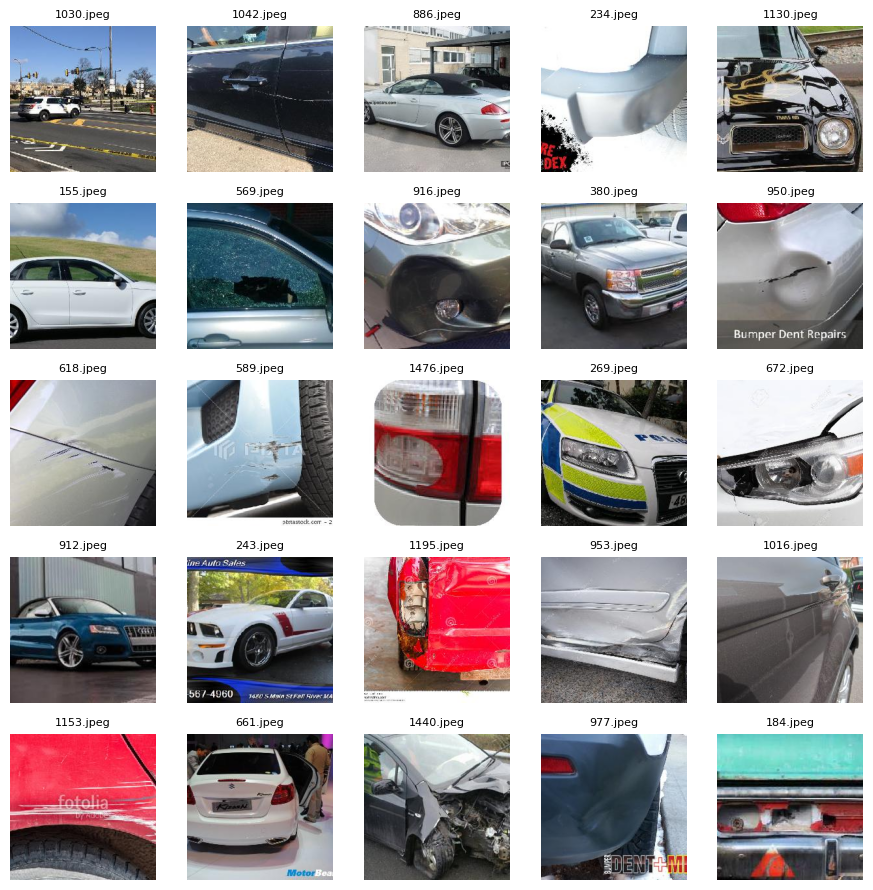

In [ ]:
# Load images dataset
cars_image_raw = Path("../../development/database/cars_damage_dataset/image")

import random
import matplotlib.pyplot as plt

# Get image files
image_files = sorted([
    p for p in cars_image_raw.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp", ".JPEG"}
])

# Pick 25 random images
sample_size = min(25, len(image_files))
random_images = random.sample(image_files, sample_size)

# Show in 5x5 grid
fig, axes = plt.subplots(5, 5, figsize=(9, 9))
axes = axes.flatten()

for ax, image_path in zip(axes, random_images):
    img = Image.open(image_path)
    ax.imshow(img)
    ax.set_title(image_path.name, fontsize=8)
    ax.axis("off")

for ax in axes[sample_size:]:
    ax.axis("off")

print(f"Total raw images cars dataset: {len(image_files)}")
print("=" * 50)
print("Cars raw dataset images classes distribution:")
print("=" * 50)
plt.tight_layout()
plt.show()

## Load training & validation cars image data

In [ ]:
from pathlib import Path

training_dir = Path("../../development/database/cars_damage_dataset/cars_image_crash_dataset_addition/training")
validation_dir = Path("../../development/database/cars_damage_dataset/cars_image_crash_dataset_addition/validation")

valid_ext = {".jpg", ".jpeg", ".png", ".webp", ".JPEG"}

cars_image_training = sorted([
    p for p in training_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in valid_ext
])

cars_image_validation = sorted([
    p for p in validation_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in valid_ext
])

print("training images:", len(cars_image_training))
print("validation images:", len(cars_image_validation))

training images: 1383
validation images: 248


Total images of training cars dataset: 1383
Training dataset images classes distribution:


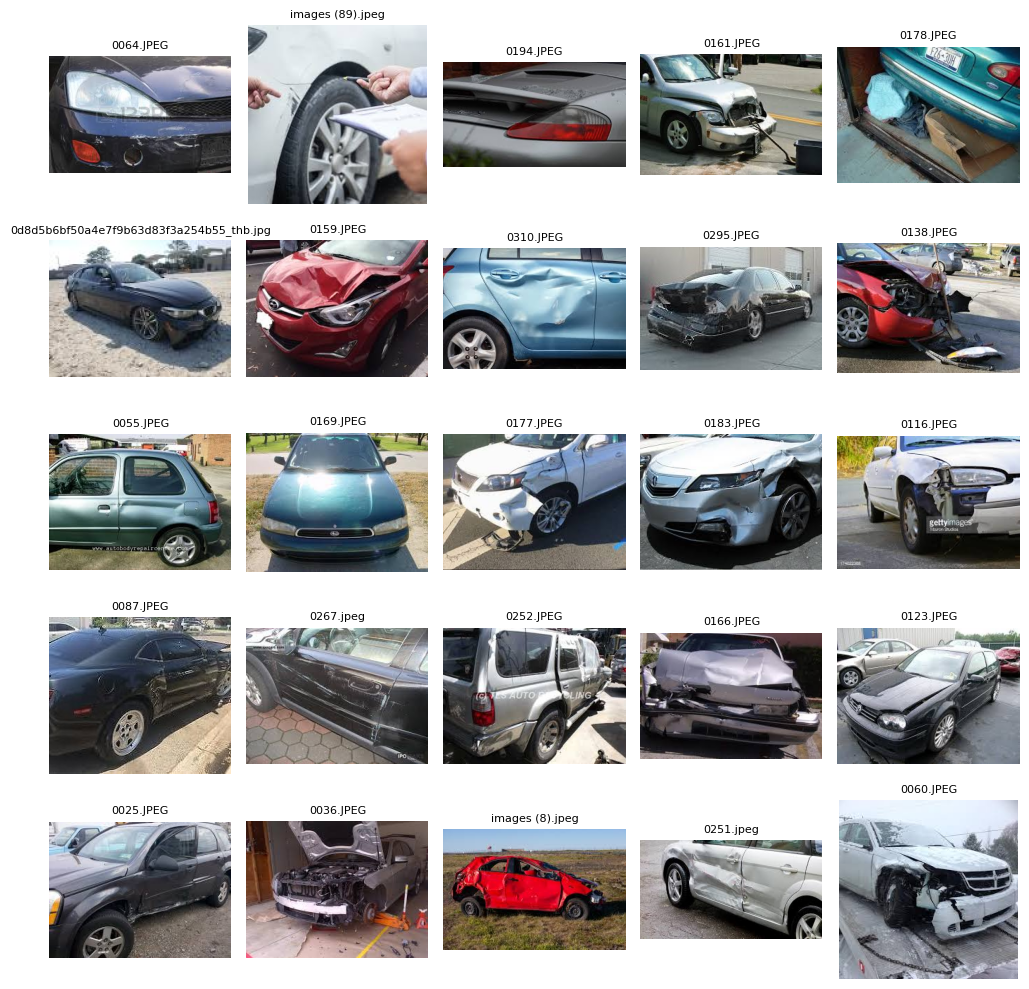

In [ ]:
# Get image files
image_files_training = sorted([
    p for p in cars_image_training
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp", ".JPEG"}
])

# Pick 25 random images
sample_size = min(25, len(image_files_training))
random_images = random.sample(image_files_training, sample_size)

# Show in 5x5 grid
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()

for ax, image_path in zip(axes, random_images):
    img = Image.open(image_path)
    ax.imshow(img)
    ax.set_title(image_path.name, fontsize=8)
    ax.axis("off")

for ax in axes[sample_size:]:
    ax.axis("off")

print(f"Total images of training cars dataset: {len(image_files_training)}")
print("=" * 50)
print("Training dataset images classes distribution:")
print("=" * 50)
plt.tight_layout()
plt.show()

Total images of validation cars dataset: 248
Validation dataset images classes distribution:


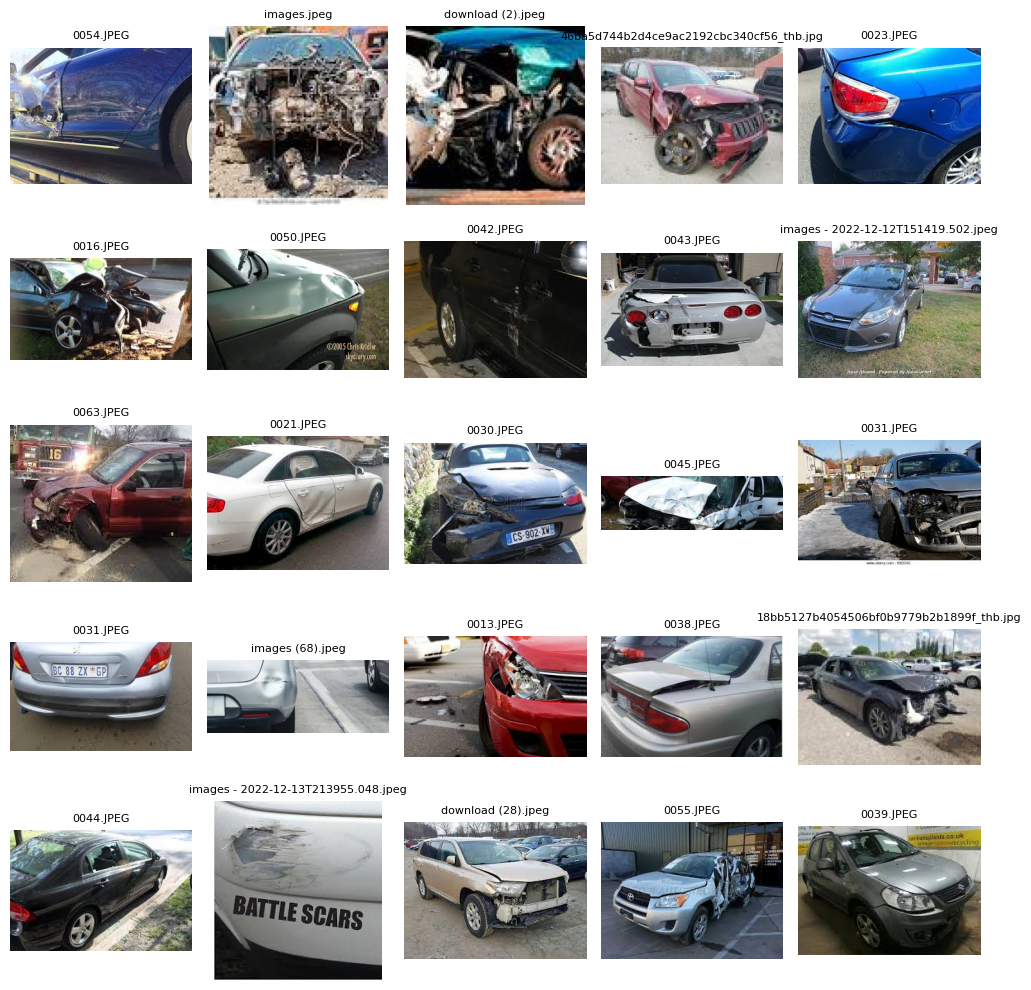

In [ ]:
# Get image files
image_files_validation = sorted([
    p for p in cars_image_validation
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp", ".JPEG"}
])

# Pick 25 random images
sample_size = min(25, len(image_files_validation))
random_images = random.sample(image_files_validation, sample_size)

# Show in 5x5 grid
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()

for ax, image_path in zip(axes, random_images):
    img = Image.open(image_path)
    ax.imshow(img)
    ax.set_title(image_path.name, fontsize=8)
    ax.axis("off")

for ax in axes[sample_size:]:
    ax.axis("off")

print(f"Total images of validation cars dataset: {len(image_files_validation)}")
print("=" * 50)
print("Validation dataset images classes distribution:")
print("=" * 50)
plt.tight_layout()
plt.show()